In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q PyYAML

In [3]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK4_REPO_ROOT = (
    REPO_ROOT / "task4"
)

TASK4_WORK_ROOT = (
    PROJECT_ROOT / "task4"
)

DATA_ROOT = (
    PROJECT_ROOT / "datasets"
)

VANILLA_CHECKPOINT_PATH = (
    TASK4_WORK_ROOT
    / "checkpoints/vanilla_best.pt"
)

PROSER_CHECKPOINT_PATH = (
    TASK4_WORK_ROOT
    / "checkpoints/proser_best.pt"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Repository:", REPO_ROOT)
print("Device:", DEVICE)
print(
    "Vanilla checkpoint exists:",
    VANILLA_CHECKPOINT_PATH.exists(),
)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Change the Colab runtime to GPU."
    )

if not VANILLA_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "The selected Vanilla checkpoint "
        "could not be found."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Repository: /content/drive/MyDrive/ATML/PA1-repo
Device: cuda
Vanilla checkpoint exists: True
GPU: Tesla T4


In [4]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import json

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml

from common.seed import set_seed

from task4.methods.proser import (
    PROSERModel,
)

from task4.models.resnet_cifar import (
    CIFARResNet18,
)

from task4.train_proser import (
    evaluate_proser_validation,
    train_proser,
)


SEED = 6304

set_seed(SEED)

with (
    TASK4_REPO_ROOT
    / "configs/base.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    base_config = yaml.safe_load(
        config_file
    )

with (
    TASK4_REPO_ROOT
    / "configs/proser.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    proser_config = yaml.safe_load(
        config_file
    )

print("Base configuration:")
print(
    yaml.safe_dump(
        base_config,
        sort_keys=False,
    )
)

print("PROSER configuration:")
print(
    yaml.safe_dump(
        proser_config,
        sort_keys=False,
    )
)

/content/drive/.shortcut-targets-by-id/1tphHcVs5KfBbfa3Y2U6Gt0Lo7AWXysa4/ATML/PA1-repo
Base configuration:
seed: 6304
dataset:
  known_dataset: CIFAR10
  unknown_dataset: CIFAR100
  validation_fraction: 0.1
  number_of_known_classes: 10
  image_size: 32
normalization:
  mean:
  - 0.4914
  - 0.4822
  - 0.4465
  standard_deviation:
  - 0.247
  - 0.2435
  - 0.2616
model:
  architecture: resnet18
  initialization: random
  first_convolution:
    kernel_size: 3
    stride: 1
    padding: 1
  initial_max_pool: false
  feature_dimension: 512
optimization:
  optimizer: SGD
  learning_rate: 0.1
  momentum: 0.9
  weight_decay: 0.0005
  scheduler: cosine
  batch_size: 128
  maximum_epochs: 100
  number_of_workers: 2
selection:
  metric: cifar10_validation_accuracy
  use_cifar100: false
evaluation:
  threshold_percentile: 95
  known_test_dataset: CIFAR10
  unknown_test_dataset: CIFAR100
unknown_groups:
  near:
  - bus
  - pickup_truck
  - motorcycle
  - tractor
  - wolf
  - fox
  - leopard
  - cam

In [5]:
import inspect

from task4.data import cifar10


print(
    "Available CIFAR-10 functions:"
)

for function_name in dir(cifar10):
    if function_name.startswith("_"):
        continue

    function_object = getattr(
        cifar10,
        function_name,
    )

    if inspect.isfunction(
        function_object
    ):
        try:
            function_signature = (
                inspect.signature(
                    function_object
                )
            )
        except Exception:
            function_signature = (
                "signature unavailable"
            )

        print(
            function_name,
            function_signature,
        )

Available CIFAR-10 functions:
build_cifar10_datasets (data_root, split, use_randaugment=False, download=True)
build_cifar10_evaluation_transform ()
build_cifar10_loaders (datasets_by_split, batch_size=128, number_of_workers=2, seed=6304)
build_cifar10_output_datasets (data_root, split, download=True)
build_cifar10_train_transform (use_randaugment=False)


In [6]:
from task4.data.cifar10 import (
    build_cifar10_datasets,
    build_cifar10_loaders,
)


split_path = (
    TASK4_REPO_ROOT
    / "splits/"
    "cifar10_train_val_seed6304.json"
)

with split_path.open(
    "r",
    encoding="utf-8",
) as split_file:
    cifar10_split = json.load(
        split_file
    )

cifar10_datasets = (
    build_cifar10_datasets(
        data_root=DATA_ROOT,
        split=cifar10_split,
        use_randaugment=False,
        download=True,
    )
)

cifar10_loaders = (
    build_cifar10_loaders(
        datasets_by_split=(
            cifar10_datasets
        ),
        batch_size=128,
        number_of_workers=2,
        seed=SEED,
    )
)

print(
    "Training samples:",
    len(cifar10_datasets["train"]),
)

print(
    "Validation samples:",
    len(cifar10_datasets["validation"]),
)

print(
    "Test samples:",
    len(cifar10_datasets["test"]),
)

print(
    "Training batches:",
    len(cifar10_loaders["train"]),
)

Training samples: 45000
Validation samples: 5000
Test samples: 10000
Training batches: 352


In [7]:
set_seed(SEED)

vanilla_checkpoint = torch.load(
    VANILLA_CHECKPOINT_PATH,
    map_location="cpu",
)

backbone = CIFARResNet18(
    number_of_outputs=10
)

backbone.load_state_dict(
    vanilla_checkpoint[
        "model_state_dict"
    ]
)

model = PROSERModel(
    backbone=backbone,
    number_of_dummy_classes=5,
).to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Vanilla selected epoch:",
    vanilla_checkpoint["epoch"],
)

print(
    "Vanilla validation score:",
    vanilla_checkpoint[
        "selection_score"
    ],
)

print(
    "Number of known classes:",
    model.number_of_known_classes,
)

print(
    "Number of dummy classes:",
    model.number_of_dummy_classes,
)

print(
    "Total parameters:",
    total_parameters,
)

print(
    "Trainable parameters:",
    trainable_parameters,
)

print(
    "Entire network trainable:",
    total_parameters
    == trainable_parameters,
)

print(
    "PROSER checkpoint:",
    PROSER_CHECKPOINT_PATH,
)

Vanilla selected epoch: 95
Vanilla validation score: 0.9516
Number of known classes: 10
Number of dummy classes: 5
Total parameters: 11176527
Trainable parameters: 11176527
Entire network trainable: True
PROSER checkpoint: /content/drive/MyDrive/ATML/PA1/task4/checkpoints/proser_best.pt


In [8]:
training_result = train_proser(
    model=model,
    train_loader=(
        cifar10_loaders["train"]
    ),
    validation_loader=(
        cifar10_loaders[
            "validation"
        ]
    ),
    device=DEVICE,
    checkpoint_path=(
        PROSER_CHECKPOINT_PATH
    ),
    maximum_epochs=50,
    learning_rate=1e-3,
    momentum=0.9,
    weight_decay=5e-4,
    mixup_alpha=2.0,
    classifier_placeholder_weight=1.0,
    data_placeholder_weight=0.1,
)

model = training_result["model"]

training_history = (
    training_result["history"]
)

selected_checkpoint = (
    training_result[
        "selected_checkpoint"
    ]
)

history_path = (
    TASK4_REPO_ROOT
    / "results/"
    "proser_training_history.csv"
)

history_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

training_history.to_csv(
    history_path,
    index=False,
)

print()
print(
    "Selected epoch:",
    selected_checkpoint["epoch"],
)

print(
    "Selected validation accuracy:",
    selected_checkpoint[
        "selection_score"
    ],
)

print(
    "History saved to:",
    history_path,
)

proser epoch 1:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 1: train loss=0.7230, validation accuracy=0.9462, best=0.9462


proser epoch 2:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 2: train loss=0.3526, validation accuracy=0.9490, best=0.9490


proser epoch 3:   0%|          | 0/352 [00:00<?, ?it/s]

...

proser epoch 49:   0%|          | 0/352 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f858c0fd080><function _MultiProcessingDataLoaderIter.__del__ at 0x7f858c0fd080>

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
self._shutdown_workers()
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()    
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
if w.is_alive():    
if w.is_alive():  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3.13/multiprocessing/process.py", line 16

Epoch 49: train loss=0.0187, validation accuracy=0.9320, best=0.9508


proser epoch 50:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 50: train loss=0.0165, validation accuracy=0.9308, best=0.9508

Selected epoch: 4
Selected validation accuracy: 0.9508
History saved to: /content/drive/MyDrive/ATML/PA1-repo/task4/results/proser_training_history.csv


In [9]:
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    f1_score,
)


def evaluate_proser_closed_set(
    model,
    data_loader,
    device,
):
    model.eval()

    all_labels = []
    all_predictions = []
    total_loss = 0.0
    total_samples = 0

    with torch.inference_mode():
        for batch in data_loader:
            images = batch["image"].to(
                device
            )

            labels = batch["label"].to(
                device
            )

            known_logits, _ = model(
                images
            )

            loss = F.cross_entropy(
                known_logits,
                labels,
                reduction="sum",
            )

            predictions = (
                known_logits.argmax(
                    dim=1
                )
            )

            total_loss += loss.item()
            total_samples += len(labels)

            all_labels.extend(
                labels.cpu().tolist()
            )

            all_predictions.extend(
                predictions.cpu().tolist()
            )

    return {
        "accuracy": accuracy_score(
            all_labels,
            all_predictions,
        ),
        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            average="macro",
        ),
        "loss": (
            total_loss
            / total_samples
        ),
        "number_of_samples": (
            total_samples
        ),
    }


closed_set_rows = []

for split_name in [
    "validation",
    "test",
]:
    split_metrics = (
        evaluate_proser_closed_set(
            model=model,
            data_loader=(
                cifar10_loaders[
                    split_name
                ]
            ),
            device=DEVICE,
        )
    )

    closed_set_rows.append(
        {
            "method": "proser",
            "split": split_name,
            **split_metrics,
        }
    )

closed_set_results = pd.DataFrame(
    closed_set_rows
)

closed_set_path = (
    TASK4_REPO_ROOT
    / "results/"
    "proser_closed_set_metrics.csv"
)

closed_set_results.to_csv(
    closed_set_path,
    index=False,
)

print(
    closed_set_results.to_string(
        index=False
    )
)

print()
print(
    "Results saved to:",
    closed_set_path,
)

method      split  accuracy  macro_f1     loss  number_of_samples
proser validation    0.9508  0.950862 0.210823               5000
proser       test    0.9465  0.946506 0.216257              10000

Results saved to: /content/drive/MyDrive/ATML/PA1-repo/task4/results/proser_closed_set_metrics.csv


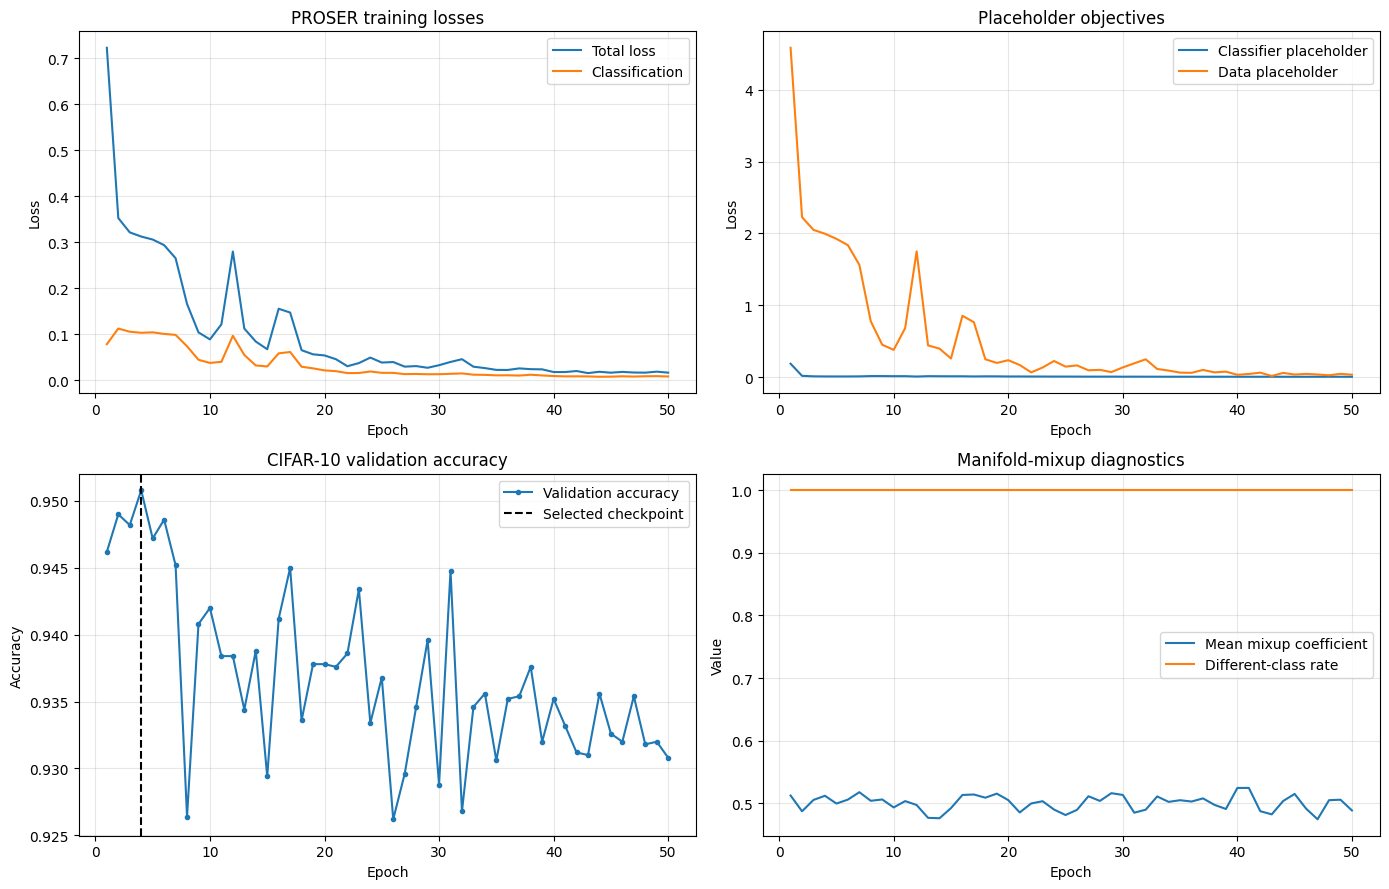

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task4/figures/proser_training_curves.png


In [10]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
)

axes[0, 0].plot(
    training_history["epoch"],
    training_history[
        "training_total_loss"
    ],
    label="Total loss",
)

axes[0, 0].plot(
    training_history["epoch"],
    training_history[
        "training_classification_loss"
    ],
    label="Classification",
)

axes[0, 0].set_title(
    "PROSER training losses"
)

axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(
    training_history["epoch"],
    training_history[
        "training_classifier_placeholder_loss"
    ],
    label="Classifier placeholder",
)

axes[0, 1].plot(
    training_history["epoch"],
    training_history[
        "training_data_placeholder_loss"
    ],
    label="Data placeholder",
)

axes[0, 1].set_title(
    "Placeholder objectives"
)

axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(
    training_history["epoch"],
    training_history[
        "validation_accuracy"
    ],
    marker=".",
    label="Validation accuracy",
)

axes[1, 0].axvline(
    selected_checkpoint["epoch"],
    color="black",
    linestyle="--",
    label="Selected checkpoint",
)

axes[1, 0].set_title(
    "CIFAR-10 validation accuracy"
)

axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(
    training_history["epoch"],
    training_history[
        "mean_mixup_coefficient"
    ],
    label="Mean mixup coefficient",
)

axes[1, 1].plot(
    training_history["epoch"],
    training_history[
        "different_class_pair_rate"
    ],
    label="Different-class rate",
)

axes[1, 1].set_title(
    "Manifold-mixup diagnostics"
)

axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Value")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

figure.tight_layout()

figure_path = (
    TASK4_REPO_ROOT
    / "figures/"
    "proser_training_curves.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [11]:
import numpy as np

from task4.scores.proser import (
    proser_mls_score,
    proser_placeholder_score,
)


def extract_proser_scores(
    model,
    data_loader,
    device,
):
    model.eval()

    rows = []

    with torch.inference_mode():
        for batch in data_loader:
            images = batch["image"].to(
                device
            )

            labels = batch["label"]

            known_logits, dummy_logits = (
                model(images)
            )

            mls_scores = (
                proser_mls_score(
                    known_logits
                )
                .cpu()
                .numpy()
            )

            placeholder_scores = (
                proser_placeholder_score(
                    known_logits,
                    dummy_logits,
                    temperature=1024.0,
                )
                .cpu()
                .numpy()
            )

            predictions = (
                known_logits.argmax(
                    dim=1
                )
                .cpu()
                .numpy()
            )

            for index in range(
                len(labels)
            ):
                rows.append(
                    {
                        "label": int(
                            labels[index]
                        ),
                        "prediction": int(
                            predictions[index]
                        ),
                        "mls": float(
                            mls_scores[index]
                        ),
                        "placeholder": float(
                            placeholder_scores[
                                index
                            ]
                        ),
                    }
                )

    return pd.DataFrame(rows)


validation_scores = (
    extract_proser_scores(
        model=model,
        data_loader=(
            cifar10_loaders[
                "validation"
            ]
        ),
        device=DEVICE,
    )
)

test_scores = extract_proser_scores(
    model=model,
    data_loader=(
        cifar10_loaders["test"]
    ),
    device=DEVICE,
)

score_thresholds = {}

for score_name in [
    "mls",
    "placeholder",
]:
    threshold = float(
        np.quantile(
            validation_scores[
                score_name
            ],
            0.95,
        )
    )

    validation_acceptance = float(
        (
            validation_scores[
                score_name
            ]
            <= threshold
        ).mean()
    )

    test_acceptance = float(
        (
            test_scores[
                score_name
            ]
            <= threshold
        ).mean()
    )

    score_thresholds[score_name] = {
        "threshold": threshold,
        "validation_acceptance_rate": (
            validation_acceptance
        ),
        "known_test_acceptance_rate": (
            test_acceptance
        ),
        "known_test_rejection_rate": (
            1.0 - test_acceptance
        ),
    }

validation_score_path = (
    TASK4_REPO_ROOT
    / "results/"
    "proser_validation_scores.csv"
)

known_score_path = (
    TASK4_REPO_ROOT
    / "results/"
    "proser_known_score_summary.csv"
)

threshold_path = (
    TASK4_REPO_ROOT
    / "results/"
    "proser_score_thresholds.json"
)

validation_scores.to_csv(
    validation_score_path,
    index=False,
)

known_summary_rows = []

for score_name, values in (
    score_thresholds.items()
):
    known_summary_rows.append(
        {
            "model": "proser",
            "score": score_name,
            **values,
        }
    )

known_score_summary = pd.DataFrame(
    known_summary_rows
)

known_score_summary.to_csv(
    known_score_path,
    index=False,
)

with threshold_path.open(
    "w",
    encoding="utf-8",
) as threshold_file:
    json.dump(
        score_thresholds,
        threshold_file,
        indent=2,
    )

print(
    known_score_summary.to_string(
        index=False
    )
)

print()
print(
    "Thresholds saved to:",
    threshold_path,
)

 model       score  threshold  validation_acceptance_rate  known_test_acceptance_rate  known_test_rejection_rate
proser         mls  -5.327534                        0.95                      0.9440                     0.0560
proser placeholder   0.000059                        0.95                      0.9449                     0.0551

Thresholds saved to: /content/drive/MyDrive/ATML/PA1-repo/task4/results/proser_score_thresholds.json


In [12]:
proser_metadata = {
    "method": "proser",
    "seed": SEED,
    "initial_checkpoint": (
        VANILLA_CHECKPOINT_PATH.name
    ),
    "initial_vanilla_epoch": int(
        vanilla_checkpoint["epoch"]
    ),
    "number_of_known_classes": 10,
    "number_of_dummy_classes": 5,
    "fine_tuning_epochs": 50,
    "optimizer": "SGD",
    "learning_rate": 1e-3,
    "momentum": 0.9,
    "weight_decay": 5e-4,
    "scheduler": "CosineAnnealingLR",
    "mixup_location": (
        "after_layer2_before_layer3"
    ),
    "mixup_alpha": 2.0,
    "different_class_pairs": True,
    "classifier_placeholder_weight": 1.0,
    "data_placeholder_weight": 0.1,
    "selected_epoch": int(
        selected_checkpoint["epoch"]
    ),
    "selection_metric": (
        selected_checkpoint[
            "selection_metric"
        ]
    ),
    "selection_score": float(
        selected_checkpoint[
            "selection_score"
        ]
    ),
    "checkpoint_filename": (
        PROSER_CHECKPOINT_PATH.name
    ),
    "placeholder_score_temperature": (
        1024.0
    ),
    "threshold_percentile": 95,
    "cifar100_used_during_training": (
        False
    ),
    "cifar100_used_for_selection": (
        False
    ),
    "closed_set_results": {
        row["split"]: {
            "accuracy": float(
                row["accuracy"]
            ),
            "macro_f1": float(
                row["macro_f1"]
            ),
            "loss": float(
                row["loss"]
            ),
            "number_of_samples": int(
                row[
                    "number_of_samples"
                ]
            ),
        }
        for row in (
            closed_set_results
            .to_dict(
                orient="records"
            )
        )
    },
    "score_thresholds": (
        score_thresholds
    ),
}

metadata_path = (
    TASK4_REPO_ROOT
    / "results/"
    "proser_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        proser_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        proser_metadata,
        indent=2,
    )
)

print()
print(
    "Metadata saved to:",
    metadata_path,
)

{
  "method": "proser",
  "seed": 6304,
  "initial_checkpoint": "vanilla_best.pt",
  "initial_vanilla_epoch": 95,
  "number_of_known_classes": 10,
  "number_of_dummy_classes": 5,
  "fine_tuning_epochs": 50,
  "optimizer": "SGD",
  "learning_rate": 0.001,
  "momentum": 0.9,
  "weight_decay": 0.0005,
  "scheduler": "CosineAnnealingLR",
  "mixup_location": "after_layer2_before_layer3",
  "mixup_alpha": 2.0,
  "different_class_pairs": true,
  "classifier_placeholder_weight": 1.0,
  "data_placeholder_weight": 0.1,
  "selected_epoch": 4,
  "selection_metric": "validation_accuracy",
  "selection_score": 0.9508,
  "checkpoint_filename": "proser_best.pt",
  "placeholder_score_temperature": 1024.0,
  "threshold_percentile": 95,
  "cifar100_used_during_training": false,
  "cifar100_used_for_selection": false,
  "closed_set_results": {
    "validation": {
      "accuracy": 0.9508,
      "macro_f1": 0.9508619955057547,
      "loss": 0.21082258959785105,
      "number_of_samples": 5000
    },
    "t

In [13]:
required_artifacts = [
    (
        TASK4_REPO_ROOT
        / "results/"
        "proser_training_history.csv"
    ),
    (
        TASK4_REPO_ROOT
        / "results/"
        "proser_closed_set_metrics.csv"
    ),
    (
        TASK4_REPO_ROOT
        / "results/"
        "proser_validation_scores.csv"
    ),
    (
        TASK4_REPO_ROOT
        / "results/"
        "proser_known_score_summary.csv"
    ),
    (
        TASK4_REPO_ROOT
        / "results/"
        "proser_score_thresholds.json"
    ),
    (
        TASK4_REPO_ROOT
        / "results/"
        "proser_metadata.json"
    ),
    (
        TASK4_REPO_ROOT
        / "figures/"
        "proser_training_curves.png"
    ),
    PROSER_CHECKPOINT_PATH,
]

all_artifacts_exist = True

for artifact_path in (
    required_artifacts
):
    exists = artifact_path.exists()

    all_artifacts_exist &= exists

    print(
        "FOUND"
        if exists
        else "MISSING",
        "|",
        artifact_path,
    )

print()
print(
    "All PROSER artifacts exist:",
    all_artifacts_exist,
)

FOUND | /content/drive/MyDrive/ATML/PA1-repo/task4/results/proser_training_history.csv
FOUND | /content/drive/MyDrive/ATML/PA1-repo/task4/results/proser_closed_set_metrics.csv
FOUND | /content/drive/MyDrive/ATML/PA1-repo/task4/results/proser_validation_scores.csv
FOUND | /content/drive/MyDrive/ATML/PA1-repo/task4/results/proser_known_score_summary.csv
FOUND | /content/drive/MyDrive/ATML/PA1-repo/task4/results/proser_score_thresholds.json
FOUND | /content/drive/MyDrive/ATML/PA1-repo/task4/results/proser_metadata.json
FOUND | /content/drive/MyDrive/ATML/PA1-repo/task4/figures/proser_training_curves.png
FOUND | /content/drive/MyDrive/ATML/PA1/task4/checkpoints/proser_best.pt

All PROSER artifacts exist: True


In [14]:
import nbformat


final_notebook_path = (
    TASK4_REPO_ROOT
    / "notebooks/"
    "05_final_evaluation.ipynb"
)

if final_notebook_path.exists():
    print(
        "Notebook already exists:",
        final_notebook_path,
    )

else:
    final_notebook = (
        nbformat.v4.new_notebook()
    )

    final_notebook.cells = [
        nbformat.v4.new_markdown_cell(
            "# Task 4 — Final Open-Set Evaluation\n\n"
            "Final evaluation on CIFAR-10 known "
            "test samples and the fixed CIFAR-100 "
            "near and far unknown groups."
        )
    ]

    final_notebook.metadata = {
        "kernelspec": {
            "display_name": "Python 3",
            "language": "python",
            "name": "python3",
        },
        "language_info": {
            "name": "python",
        },
    }

    nbformat.write(
        final_notebook,
        final_notebook_path,
    )

    print(
        "Created:",
        final_notebook_path,
    )

Created: /content/drive/MyDrive/ATML/PA1-repo/task4/notebooks/05_final_evaluation.ipynb
